## Package

In [1]:
import datetime
import pandas as pd
import numpy as np
import os
import sys
import pytz
from numpy.typing import ArrayLike, DTypeLike, NDArray
from typing import Sequence, List, Dict, Tuple, Set, Any, Union, Optional, Annotated, Callable, Literal, TypeVar
from loguru import logger

## Constant config

In [2]:
FILE_PATH: str = "/home/user/data-da-ds-de/prj1mrdp/data/raw/sales_data_sample.xlsx"
SHEET_NAME: str = "Sales_Data"

In [3]:
DATE_FORMAT: str = "%Y-%m-%d"
DATETIME_FORMAT: str = "%Y-%m-%d HH:MM:SS"
today: str = datetime.datetime.now().strftime(DATE_FORMAT)
today

'2025-12-05'

In [4]:
logger.remove()

logger.add(
    sys.stdout,
    colorize=True
)

logger.add(
    f"/home/user/data-da-ds-de/lab/logs/{today}.log",
    colorize=False,
    format="[{level}][{time}][{name}] {message}"
)

2

## Data sample

In [5]:
df = pd.read_excel(FILE_PATH, SHEET_NAME)

In [6]:
df.head()

,Order_ID,Date,Category,Region,Customer_Segment,Payment_Method,Quantity,Unit_Price,Discount_Rate,Customer_Rating,Returned,Subcategory,Total_Price,Discount_Amount,Net_Sales,Shipping_Cost,Profit_Margin,Profit,Month
0,ORD-10000,2024-07-12,Books,East,Business,PayPal,1,316.58,0.20,5.0,False,Comics,316.58,63.3160,253.2640,0.0,0.33,83.577120,2024-07
1,ORD-10001,2025-03-15,Sports,West,Premium,Bank Transfer,5,279.76,0.10,NaN,True,Water Sports,1398.80,139.8800,1258.9200,0.0,0.20,251.784000,2025-03
2,ORD-10002,2024-12-27,Home & Kitchen,Central,Business,Bank Transfer,6,209.61,0.05,4.0,False,Furniture,1257.66,62.8830,1194.7770,0.0,0.37,442.067490,2024-12
3,ORD-10003,2024-07-16,Home & Kitchen,North,Regular,Credit Card,3,265.47,0.15,4.0,False,Kitchenware,796.41,119.4615,676.9485,0.0,0.23,155.698155,2024-07
4,ORD-10004,2024-06-11,Electronics,North,New,Bank Transfer,9,449.32,0.00,4.0,False,Accessories,4043.88,0.0000,4043.8800,0.0,0.37,1496.235600,2024-06


In [7]:
df = df.convert_dtypes()

In [8]:
df["validation_result"] = [set() for _ in range(df.shape[0])]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           1000 non-null   string        
 1   Date               1000 non-null   datetime64[ns]
 2   Category           1000 non-null   string        
 3   Region             1000 non-null   string        
 4   Customer_Segment   1000 non-null   string        
 5   Payment_Method     1000 non-null   string        
 6   Quantity           1000 non-null   Int64         
 7   Unit_Price         1000 non-null   Float64       
 8   Discount_Rate      949 non-null    Float64       
 9   Customer_Rating    945 non-null    Int64         
 10  Returned           1000 non-null   boolean       
 11  Subcategory        1000 non-null   string        
 12  Total_Price        1000 non-null   Float64       
 13  Discount_Amount    1000 non-null   Float64       
 14  Net_Sales

## Basic
- For starter, just create function to validate data, improvement it, cover all possible cases, then implement and make it better later

- input: pd.Series/ column, that has specify nan value
- output: error and index values of each error

- Befor test, must selet and convert dtype to correct dtype, change format, split data, transform, pre processing before test. Meaning value is clean in basic.

### Error message and function add error message

In [ ]:
error_message: Dict[str, any] = {
    "check_mandatory": "[{}][Check mandatory] Required field.",
    "check_data_type": "[{}][Check data type] Data type must be '{}'.",
    "check_in_range_numeric": "[{}][Check in range numeric] Value must be in range [{}, {}].",
    "check_correct_datetime_format": "[{}][Check correct datetime format] Value must be correct format: '{}'.",
    "check_in_range_datetime": "[{}][Check in range datetime] Value must be in range [{}, {}].",
    "check_in_range_string_length": "[{}][Check in range string length] Data length must be in range [{}, {}]."
}

In [11]:
def add_message_function(message: str = "") -> set:
    return lambda _: _.union({message})

### Data type

In [12]:
type NumberType = Sequence[int, float, None, np.nan, pd.NA] | NDArray[np.int64, None, np.nan, pd.NA] | NDArray[np.float64, None, np.nan, pd.NA]

type StringType = Sequence[str, None, np.nan, pd.NA] | NDArray[np.strings, None, np.nan, pd.NA]

type BoolType = Sequence[bool, None, np.nan, pd.NA] | NDArray[np.bool, None, np.nan, pd.NA]

### Check common

In [ ]:
# Check common:
# empty
# if not empty => check other
# data range
# format
# logic
# fill default value for missing data
# Enum value or mapping value?

# Before check, need ensure column name is correct, df is not empty, and column validation_result is added set() value for each cell

#### check empty

In [ ]:
# determine columns contain na value
na_value_count: pd.Series = df.isna().sum()
na_value_count[na_value_count > 0].index.tolist()

In [ ]:
# determine columns contain user-defined empty values
empty_value_count = df.astype(str).isin(["", "nan"]).sum()
empty_value_count[empty_value_count > 0].index.tolist()

In [ ]:
# check is na for df
df_empty_check:pd.DatFrame = df.isna()
df_empty_check.head()

In [ ]:
# summarize column and value na in df
df.isna().sum()

In [ ]:
# check value is in empty value or not
df.astype(str).isin(["", "nan"]).sum()

In [ ]:
# check sample column has na value
df_empty_check['Discount_Rate'].where(df_empty_check['Discount_Rate']).dropna().index.shape

In [13]:
@logger.catch
def is_empty(sr: ArrayLike = None, empty_value_list: ArrayLike| Dict|Tuple|Set = None) -> pd.Series:
    """Return True if cell value is empty value else False."""
    mask: pd.Series = sr.isna()
    if empty_value_list:
        mask = mask | sr.isin(empty_value_list)
    return mask

In [14]:
# test with sample data
is_empty(pd.Series([1,2,3, np.nan]))

0    False
1    False
2    False
3     True
dtype: bool

In [15]:
@logger.catch
def check_mandatory(df: pd.DataFrame = None, column_name: str = "", empty_value_list: list = None) -> pd.DataFrame:
    """Return error message if value cell is empty, else none."""

    message: str = error_message["check_mandatory"].format(column_name)
    empty_result: pd.Series = is_empty(df[column_name])
    df.loc[empty_result, "validation_result"] = df.loc[empty_result, "validation_result"].map(add_message_function(message))
    return df


In [18]:
# test with data
df_check_mandatory: pd.DataFrame = df.copy()
check_mandatory(df_check_mandatory, "Discount_Rate").head()

,Order_ID,Date,Category,Region,Customer_Segment,Payment_Method,Quantity,Unit_Price,Discount_Rate,Customer_Rating,Returned,Subcategory,Total_Price,Discount_Amount,Net_Sales,Shipping_Cost,Profit_Margin,Profit,Month,validation_result
0,ORD-10000,2024-07-12,Books,East,Business,PayPal,1,316.58,0.2,5,False,Comics,316.58,63.316,253.264,0.0,0.33,83.57712,2024-07,{}
1,ORD-10001,2025-03-15,Sports,West,Premium,Bank Transfer,5,279.76,0.1,<NA>,True,Water Sports,1398.8,139.88,1258.92,0.0,0.2,251.784,2025-03,{}
2,ORD-10002,2024-12-27,Home & Kitchen,Central,Business,Bank Transfer,6,209.61,0.05,4,False,Furniture,1257.66,62.883,1194.777,0.0,0.37,442.06749,2024-12,{}
3,ORD-10003,2024-07-16,Home & Kitchen,North,Regular,Credit Card,3,265.47,0.15,4,False,Kitchenware,796.41,119.4615,676.9485,0.0,0.23,155.698155,2024-07,{}
4,ORD-10004,2024-06-11,Electronics,North,New,Bank Transfer,9,449.32,0.0,4,False,Accessories,4043.88,0.0,4043.88,0.0,0.37,1496.2356,2024-06,{}


In [19]:
# Check result of function
df_check_mandatory.where(df_check_mandatory["validation_result"].map(lambda x: len(x) > 0)).dropna(how="all").head()

,Order_ID,Date,Category,Region,Customer_Segment,Payment_Method,Quantity,Unit_Price,Discount_Rate,Customer_Rating,Returned,Subcategory,Total_Price,Discount_Amount,Net_Sales,Shipping_Cost,Profit_Margin,Profit,Month,validation_result
10,ORD-10010,2025-02-25,Clothing,East,Business,Bank Transfer,6,302.5,<NA>,3,False,Women,1815.0,272.25,1542.75,0.0,0.29,447.3975,2025-02,{[Discount_Rate] Required field.}
101,ORD-10101,2024-06-02,Books,West,Business,Debit Card,8,131.78,<NA>,2,False,Fiction,1054.24,105.424,948.816,0.0,0.37,351.06192,2024-06,{[Discount_Rate] Required field.}
119,ORD-10119,2024-07-08,Home & Kitchen,East,New,PayPal,8,403.17,<NA>,2,False,Bedding,3225.36,645.072,2580.288,0.0,0.3,774.0864,2024-07,{[Discount_Rate] Required field.}
134,ORD-10134,2024-04-15,Home & Kitchen,Central,Regular,Cash on Delivery,6,133.63,<NA>,2,False,Decor,801.78,40.089,761.691,0.0,0.38,289.44258,2024-04,{[Discount_Rate] Required field.}
137,ORD-10137,2024-09-26,Sports,East,Premium,PayPal,4,36.28,<NA>,<NA>,False,Team Sports,145.12,0.0,145.12,8.82,0.25,36.28,2024-09,{[Discount_Rate] Required field.}


#### Convert dtype type

In [ ]:
pd.options.future.infer_string = True
# https://pandas.pydata.org/docs/user_guide/options.html

In [ ]:
str_type_columns: pd.Series = df.select_dtypes(include="str").columns
str_type_columns
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html

In [ ]:
numeric_type_columns: pd.Series = df.select_dtypes(include="number").columns
numeric_type_columns

In [ ]:
datetime_type_columns: pd.Series = df.select_dtypes(include=[np.datetime64, np.timedelta64, "datetimetz"]).columns
datetime_type_columns

In [ ]:
bool_type_columns: pd.Series = df.select_dtypes(include="bool").columns
bool_type_columns

In [ ]:
# befor check, need convert to willing dtype first, by using config
convert_dtypes: Dict[str, any] = {
    "Order_ID": "object",
    "Date": "datetime64[ns]",
}
df_test_convert_dtypes: pd.DataFrame = df.copy()
df_test_convert_dtypes = df_test_convert_dtypes.astype(convert_dtypes)
df_test_convert_dtypes.info()

# if not use df.convert_dtypes() to nearly match dtype of each column

### Check detail of number type

In [ ]:
# For data type: number: int, float
# check type => isinstance, type, pd.to_numeric()
# range: pd.eq(), pd.lt(), pd.gt(), <= or >=, query or pd.between(lower, upper, inclusive=True) if inclusive true: range is [],else[)
# np.select()?
# output: index of incorrect value



#### chec data type

- Prequisite: None
- Output: validation result add message if not in range, else ignore

In [ ]:
@logger.catch
def is_numeric(sr: pd.Series) -> pd.Series:
    """Return True if each value cell is numeric or False if not."""
    return pd.to_numeric(sr, errors="coerce").notna()

In [86]:
@logger.catch
def check_numeric(df: pd.DataFrame = None, column_name: str = "",
    ) -> pd.DataFrame:
    """Return error message if value is not numeric else no message."""

    message: str = error_message["check_data_type"].format(column_name, "number")
    empty_check: pd.Series = is_empty(df[column_name])
    numeric_check: pd.Series = is_numeric(df[column_name])
    mask = ~empty_check & ~numeric_check
    df.loc[mask, "validation_result"] = df.loc[mask, "validation_result"].map(add_message_function(message))
    return df


In [ ]:
df_check_numeric: pd.DataFrame = pd.DataFrame(
    {
        "1": [
            1,
            2,
            3,
            "abc",
            np.nan
        ],
        "validation_result": [set() for _ in range(5)]
    }
)


In [61]:
from pandas.api.types import is_float_dtype, is_integer_dtype
is_integer_dtype(df_check_numeric["1"])

False

In [ ]:
# # just test
# pd.set_option('future.no_silent_downcasting', False)
# mask_check_numeric: pd.Series = df_check_numeric["1"].map(
#     lambda _:
#     not isinstance(_, float) and
#     not isinstance(_, int),
#     na_action="ignore"
#     ).fillna(False)
# mask_check_numeric = mask_check_numeric.infer_objects(copy=False)
# mask_check_numeric

/tmp/ipykernel_273/114828823.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(False)


0    False
1    False
2    False
3     True
4    False
Name: 1, dtype: bool

In [ ]:
# # just test
# df_check_numeric.loc[mask_check_numeric, "validation_result"] = df_check_numeric.loc[mask_check_numeric, "validation_result"].map(
#     lambda _:
#     _ | {"Not float type"}
# )

In [56]:
df_check_numeric

,1,validation_result
0,1,{}
1,2,{}
2,3,{}
3,abc,{Not float type}
4,NaN,{}


In [ ]:
# Test with sample data
check_numeric(df_check_numeric,
column_name="1"
)

,1,validation_result
0,1,{}
1,2,{}
2,3,{}
3,abc,{[1] Data type must be 'number'.}
4,NaN,{}


In [55]:
# test with dataset
df_test_check_numeric: pd.DataFrame = df.copy()
check_numeric(df_test_check_numeric, "Discount_Rate")
df_test_check_numeric[df_test_check_numeric["validation_result"].map(lambda x: len(x) > 0)].head()

,Order_ID,Date,Category,Region,Customer_Segment,Payment_Method,Quantity,Unit_Price,Discount_Rate,Customer_Rating,Returned,Subcategory,Total_Price,Discount_Amount,Net_Sales,Shipping_Cost,Profit_Margin,Profit,Month,validation_result


#### check range

- Prequisite: convert to numeric and np.nan
- Output: validation result add message if not in range, else ignore

In [88]:
@logger.catch
def check_in_range_numeric(
    df: pd.DataFrame = None,
    column_name: str = "",
    input_range: Tuple[int | float, int | float] = (0, 0),
) -> pd.DataFrame:
    """Return error message if cell value is not in range, else no message. Ignore empty value ro not numeric values."""
    if input_range[0] > input_range[1]:
        input_range = (input_range[1], input_range[0])

    message: str = error_message["check_in_range_numeric"].format(
        column_name, input_range[0], input_range[1]
    )

    # values considered "empty"
    empty_mask: pd.Series = is_empty(df[column_name])

    # convert to numeric; non-numeric → NaN
    numeric_col = pd.to_numeric(df[column_name], errors="coerce")

    # non-numeric --> NaN --> will be ignored
    non_numeric_mask = numeric_col.isna() & (~empty_mask)

    # check numeric values in range
    range_mask = numeric_col.between(input_range[0], input_range[1], inclusive="both")

    # invalid only if:
    #   - numeric
    #   - NOT empty
    #   - NOT in range
    invalid_mask = (~range_mask) & (~empty_mask) & (~non_numeric_mask)

    df.loc[invalid_mask, "validation_result"] = df.loc[invalid_mask, "validation_result"].map(add_message_function(message))

    return df


In [89]:
df_test_in_range_numeric: pd.DataFrame = pd.DataFrame({
    "1": [1,2,3, "abc", np.nan],
    "validation_result": [set() for _ in range(5)]
})
check_in_range_numeric(
    df=df_test_in_range_numeric,
    column_name="1",
    input_range=(4,5)
)

,1,validation_result
0,1,"{[1] Value must be in range [4, 5].}"
1,2,"{[1] Value must be in range [4, 5].}"
2,3,"{[1] Value must be in range [4, 5].}"
3,abc,{}
4,NaN,{}


In [58]:
df["validation_result"] = [set() for _ in range(df.shape[0])]

In [59]:
check_in_range_numeric(df, "Discount_Rate", (0.5, 1)).head()

,Order_ID,Date,Category,Region,Customer_Segment,Payment_Method,Quantity,Unit_Price,Discount_Rate,Customer_Rating,Returned,Subcategory,Total_Price,Discount_Amount,Net_Sales,Shipping_Cost,Profit_Margin,Profit,Month,validation_result
0,ORD-10000,2024-07-12,Books,East,Business,PayPal,1,316.58,0.2,5,False,Comics,316.58,63.316,253.264,0.0,0.33,83.57712,2024-07,"{[Discount_Rate] Value must be in range [0.5, 1]}"
1,ORD-10001,2025-03-15,Sports,West,Premium,Bank Transfer,5,279.76,0.1,<NA>,True,Water Sports,1398.8,139.88,1258.92,0.0,0.2,251.784,2025-03,"{[Discount_Rate] Value must be in range [0.5, 1]}"
2,ORD-10002,2024-12-27,Home & Kitchen,Central,Business,Bank Transfer,6,209.61,0.05,4,False,Furniture,1257.66,62.883,1194.777,0.0,0.37,442.06749,2024-12,"{[Discount_Rate] Value must be in range [0.5, 1]}"
3,ORD-10003,2024-07-16,Home & Kitchen,North,Regular,Credit Card,3,265.47,0.15,4,False,Kitchenware,796.41,119.4615,676.9485,0.0,0.23,155.698155,2024-07,"{[Discount_Rate] Value must be in range [0.5, 1]}"
4,ORD-10004,2024-06-11,Electronics,North,New,Bank Transfer,9,449.32,0.0,4,False,Accessories,4043.88,0.0,4043.88,0.0,0.37,1496.2356,2024-06,"{[Discount_Rate] Value must be in range [0.5, 1]}"


### Check detail of string type

In [ ]:
# string
# mapping value: True, False, None,...
# length
# value list
# format
# separator
# white space
# special charater
# sub str in/not in value


In [28]:
pd.Series(["1", "22"]).astype(str).str.len()

0    1
1    2
dtype: int64

In [37]:
@logger.catch
def is_string_length_in_range(sr: pd.Series = None, lower_range: int = 0, upper_range: int = 0) -> pd.Series:
    """Resturn True if string is not in range, else False."""
    mask: pd.Series = sr.map(lambda _: lower_range <= len(_) <= upper_range)
    return mask

In [46]:
def add_new_message(df: pd.DataFrame = None, mask: pd.Series = None, message: str = "") -> pd.DataFrame:
    df.loc[mask, "validation_result"] = df.loc[mask, "validation_result"].map(lambda _: _.union({message}))
    return df

In [49]:
@logger.catch
def check_in_range_string_length(df: pd.DataFrame = None, column_name: str = "", length_range=Tuple[int, int]) -> pd.DataFrame:
    """Return error message for each cell if string value is out of range, else none."""
    lower_range: int = length_range[0]
    upper_range: int = length_range[1]
    if lower_range > upper_range:
        lower_range, upper_range = upper_range, lower_range
    message: str = error_message["check_in_range_string_length"].format(column_name, length_range[0], length_range[1])

    empty_mask: pd.Series = is_empty(df[column_name])
    # Just check not empty cell
    # Assume that all are str
    not_in_range_mask: pd.Series = is_string_length_in_range(df[column_name], lower_range, upper_range)
    mask: pd.Series = ~empty_mask & ~not_in_range_mask

    # df.loc[mask, "validation_result"] = df.loc[mask, "validation_result"].map(add_message_function(message))
    return add_new_message(df, mask, message)


In [50]:
# test with data
df_not_in_range_mask: pd.DataFrame = df.copy()
check_in_range_string_length(df_not_in_range_mask, "Order_ID", (0,5)).head().loc[0, "validation_result"]

{'[Order_ID][Check in range string length] Data length must be in range[0, 5].'}

### Check detail of datetime type

In [ ]:
# datetime
# format
# range
# 

#### Check datetime format

In [67]:
@logger.catch
def is_correct_datetime_format(
    sr: pd.Series = None,
    input_format: str = "%Y-%m-%d"
    ) -> pd.Series:
    """Return True in each cell if can be converted to datetime follow format, else False."""
    return pd.to_datetime(sr, errors="coerce", format=input_format).notna()


In [77]:
# test with sample data
df_test_corect_datetime_format: pd.DataFrame = pd.DataFrame({
    "datetime": ["2025-11-01", "2025-11-01 00:00:00", np.nan],
    "validation_result": [set() for _ in range(3)]
})
is_correct_datetime_format(df_test_corect_datetime_format["datetime"])

0     True
1    False
2    False
Name: datetime, dtype: bool

In [75]:
@logger.catch
def check_correct_datetime_format(df: pd.DataFrame = None, column_name: str = "", datetime_format: str = "%Y-%m-%d") -> pd.DataFrame:
    """Return error message if cell value is incorrect datetime format else no message. Ignore empty value."""
    message: str = error_message["check_correct_datetime_format"].format(column_name, datetime_format)

    empty_mask: pd.Series = is_empty(df[column_name])

    correct_format_mask: pd.Series = is_correct_datetime_format(df[column_name], datetime_format)

    # Invalid value is:
    # - Not empty
    # - Wrong input format
    mask: pd.Series = ~empty_mask & ~correct_format_mask

    df.loc[mask, "validation_result"] = df.loc[mask, "validation_result"].map(add_message_function(message))
    return df

In [78]:
# test with sample data
check_correct_datetime_format(df_test_corect_datetime_format, "datetime")

,datetime,validation_result
0,2025-11-01,{}
1,2025-11-01 00:00:00,{[datetime] Value must be correct format: '%Y-...
2,NaN,{}


#### Check range datetime

In [113]:
@logger.catch
def is_in_range_datetime(sr: pd.Series, range: Tuple[str, any]) -> pd.Series:
    "Return pd.Series, contains value True if cell value is in rage else False."
    return (range[0] <= sr) & (sr <= range[1])

In [114]:
is_in_range_datetime(df_test_corect_datetime_format["datetime"], ("2025-01-01", "2026-01-01"))

0     True
1     True
2    False
Name: datetime, dtype: bool

In [115]:
@logger.catch
def check_in_range_datetime(
    df: pd.DataFrame = None,
    column_name: str = "",
    range: Tuple[str, any] = ("", ""),
    datetime_format: str = "%Y-%m-%d"
    ) -> pd.DataFrame:
    """Return error message if datetime value in cell is not in range, else no message. Ignore empty values."""
    message: str = error_message["check_in_range_datetime"].format(column_name, range[0], range[1])

    sr_datetime: pd.Series = pd.to_datetime(df[column_name], errors="coerce", format=datetime_format)
    lower_range = pd.to_datetime(range[0], format=datetime_format)
    upper_range = pd.to_datetime(range[1], format=datetime_format)
    if pd.to_datetime(range[0]) > pd.to_datetime(range[1]):
        lower_range, upper_range = upper_range, lower_range

    empty_mask: pd.Series = is_empty(df[column_name])

    in_range_mask: pd.Series = is_in_range_datetime(df[column_name], range)

    mask: pd.Series = ~empty_mask & ~in_range_mask

    df.loc[mask, "validation_result"] = df.loc[mask, "validation_result"].map(add_message_function(message))
    return df

In [117]:
check_in_range_datetime(df_test_corect_datetime_format, "datetime", ("2024-01-01", "2025-01-01"))

,datetime,validation_result
0,2025-11-01,{[datetime] Value must be in range [2024-01-01...
1,2025-11-01 00:00:00,{[datetime] Value must be in range [2024-01-01...
2,NaN,{}


### Check detail of time series type

In [ ]:
# time series

### Check detail of category type

In [ ]:
# category


## Check detail of object type

- Value in list

## Test with dataset

In [118]:
df.head()

,Order_ID,Date,Category,Region,Customer_Segment,Payment_Method,Quantity,Unit_Price,Discount_Rate,Customer_Rating,Returned,Subcategory,Total_Price,Discount_Amount,Net_Sales,Shipping_Cost,Profit_Margin,Profit,Month,validation_result
0,ORD-10000,2024-07-12,Books,East,Business,PayPal,1,316.58,0.2,5,False,Comics,316.58,63.316,253.264,0.0,0.33,83.57712,2024-07,{}
1,ORD-10001,2025-03-15,Sports,West,Premium,Bank Transfer,5,279.76,0.1,<NA>,True,Water Sports,1398.8,139.88,1258.92,0.0,0.2,251.784,2025-03,{}
2,ORD-10002,2024-12-27,Home & Kitchen,Central,Business,Bank Transfer,6,209.61,0.05,4,False,Furniture,1257.66,62.883,1194.777,0.0,0.37,442.06749,2024-12,{}
3,ORD-10003,2024-07-16,Home & Kitchen,North,Regular,Credit Card,3,265.47,0.15,4,False,Kitchenware,796.41,119.4615,676.9485,0.0,0.23,155.698155,2024-07,{}
4,ORD-10004,2024-06-11,Electronics,North,New,Bank Transfer,9,449.32,0.0,4,False,Accessories,4043.88,0.0,4043.88,0.0,0.37,1496.2356,2024-06,{}


In [ ]:
# convert to correct data format

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           1000 non-null   string        
 1   Date               1000 non-null   datetime64[ns]
 2   Category           1000 non-null   string        
 3   Region             1000 non-null   string        
 4   Customer_Segment   1000 non-null   string        
 5   Payment_Method     1000 non-null   string        
 6   Quantity           1000 non-null   Int64         
 7   Unit_Price         1000 non-null   Float64       
 8   Discount_Rate      949 non-null    Float64       
 9   Customer_Rating    945 non-null    Int64         
 10  Returned           1000 non-null   boolean       
 11  Subcategory        1000 non-null   string        
 12  Total_Price        1000 non-null   Float64       
 13  Discount_Amount    1000 non-null   Float64       
 14  Net_Sales

In [142]:
# split date time to seperate month, year, day
df["Year"] = pd.to_datetime(df["Date"], errors="coerce").dt.year
df["Month"] = pd.to_datetime(df["Date"], errors="coerce").dt.month
df["Day"] = pd.to_datetime(df["Date"], errors="coerce").dt.day

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           1000 non-null   string        
 1   Date               1000 non-null   datetime64[ns]
 2   Category           1000 non-null   string        
 3   Region             1000 non-null   string        
 4   Customer_Segment   1000 non-null   string        
 5   Payment_Method     1000 non-null   string        
 6   Quantity           1000 non-null   Int64         
 7   Unit_Price         1000 non-null   Float64       
 8   Discount_Rate      949 non-null    Float64       
 9   Customer_Rating    945 non-null    Int64         
 10  Returned           1000 non-null   boolean       
 11  Subcategory        1000 non-null   string        
 12  Total_Price        1000 non-null   Float64       
 13  Discount_Amount    1000 non-null   Float64       
 14  Net_Sales

In [144]:
# category data by type
# int type
int_type_column_list: List = df.select_dtypes(include="int").columns.tolist()
int_type_column_list

['Quantity', 'Customer_Rating', 'Month', 'Year', 'Day']

In [145]:
# float type
float_type_column_list: List = df.select_dtypes(include="float").columns.tolist()
float_type_column_list

['Unit_Price',
 'Discount_Rate',
 'Total_Price',
 'Discount_Amount',
 'Net_Sales',
 'Shipping_Cost',
 'Profit_Margin',
 'Profit']

In [146]:
# check int + float column equal to number column
number_type_column_list: list = df.select_dtypes(include="number").columns.tolist()
print(number_type_column_list)
print(len(number_type_column_list) == len(int_type_column_list) + len(float_type_column_list))

['Quantity', 'Unit_Price', 'Discount_Rate', 'Customer_Rating', 'Total_Price', 'Discount_Amount', 'Net_Sales', 'Shipping_Cost', 'Profit_Margin', 'Profit', 'Month', 'Year', 'Day']
True


In [147]:
# bool type
bool_column_list: list = df.select_dtypes(include="bool").columns.tolist()
bool_column_list

['Returned']

In [148]:
# string type
str_column_list: list = df.select_dtypes(include="string").columns.tolist()
str_column_list

['Order_ID',
 'Category',
 'Region',
 'Customer_Segment',
 'Payment_Method',
 'Subcategory']

In [149]:
# datetime type
datetime_column_list: list = df.select_dtypes(include="datetime").columns.tolist()
datetime_column_list

['Date']

In [ ]:
# object type
# must apply these step before add validation_result column
object_column_list: list = df.select_dtypes(include="object").columns.tolist()
object_column_list

['validation_result']

In [150]:
df["validation_result"] = [set() for _ in range(df.shape[0])]

In [154]:
# Check empty for all column, except validation resul
tempty_checked_column_list: List = df.columns.to_list()
tempty_checked_column_list.remove("validation_result")
print(tempty_checked_column_list)

['Order_ID', 'Date', 'Category', 'Region', 'Customer_Segment', 'Payment_Method', 'Quantity', 'Unit_Price', 'Discount_Rate', 'Customer_Rating', 'Returned', 'Subcategory', 'Total_Price', 'Discount_Amount', 'Net_Sales', 'Shipping_Cost', 'Profit_Margin', 'Profit', 'Month', 'Year', 'Day']


In [155]:
for col in tempty_checked_column_list:
    check_mandatory(df, col)

In [158]:
df["validation_result"].where(df["validation_result"].map(lambda x: len(x) > 0)).dropna()

1      {[Customer_Rating] Required field.}
10       {[Discount_Rate] Required field.}
14       {[Shipping_Cost] Required field.}
25     {[Customer_Rating] Required field.}
35     {[Customer_Rating] Required field.}
                      ...                 
983      {[Discount_Rate] Required field.}
984      {[Shipping_Cost] Required field.}
987      {[Shipping_Cost] Required field.}
988      {[Shipping_Cost] Required field.}
992      {[Discount_Rate] Required field.}
Name: validation_result, Length: 142, dtype: object

In [160]:
# check number type
for col in number_type_column_list:
    check_numeric(df, col)

In [ ]:
# check in range fir number type
check_in_range_numeric(df, "Discount_Rate", (0, 1))

In [ ]:
check_in_range_numeric(df, "Customer_Rating", (1, 5))


In [ ]:
# string bool to bool:
df["Returned"].unique()
# this column: lowercase, strip, remove special character and final mapping: {"true": True, "false": False} or other: "unknown" if npot detect or np.nan if NA like

<BooleanArray>
[False, True]
Length: 2, dtype: boolean

## Summarize datavalidation report


In [ ]:
# Split validation_result column in report
import re

text = "[Customer_Rating][Check mandatory] Required field."

column, error_type = re.findall(r"\[(.*?)\]", text)
print(column, error_type)

In [2]:
import pandas as pd
import numpy as np

In [9]:
report_file_path: str = "/home/user/data-da-ds-de/reports/2025-11-29.xlsx"
df_report = pd.read_excel(report_file_path, usecols=["Excel_Index", "Order_ID", "validation_result"])
df_report.head()

,Excel_Index,Order_ID,validation_result
0,7,ORD-10493,[Region - Check mandatory] Required field.
1,8,ORD-10927,[Quantity - Check mandatory] Required field.\n...
2,11,ORD-10987,[Shipping_Cost - Check mandatory] Required field.
3,18,ORD-10572,[Customer_Rating - Check mandatory] Required f...
4,20,ORD-10854,[Customer_Rating - Check mandatory] Required f...


In [10]:
import re
df_report["column_error"] = df_report["validation_result"].map(lambda _: _.split("]")[0].replace("[", ""))
df_report.head()

,Excel_Index,Order_ID,validation_result,column_error
0,7,ORD-10493,[Region - Check mandatory] Required field.,Region - Check mandatory
1,8,ORD-10927,[Quantity - Check mandatory] Required field.\n...,Quantity - Check mandatory
2,11,ORD-10987,[Shipping_Cost - Check mandatory] Required field.,Shipping_Cost - Check mandatory
3,18,ORD-10572,[Customer_Rating - Check mandatory] Required f...,Customer_Rating - Check mandatory
4,20,ORD-10854,[Customer_Rating - Check mandatory] Required f...,Customer_Rating - Check mandatory


In [13]:
df_report["column_error"] = df_report["column_error"].map(lambda _: _.split(" - "))
df_report.head()

,Excel_Index,Order_ID,validation_result,column_error,"(column, error_type)"
0,7,ORD-10493,[Region - Check mandatory] Required field.,"[Region, Check mandatory]","[Region, Check mandatory]"
1,8,ORD-10927,[Quantity - Check mandatory] Required field.\n...,"[Quantity, Check mandatory]","[Quantity, Check mandatory]"
2,11,ORD-10987,[Shipping_Cost - Check mandatory] Required field.,"[Shipping_Cost, Check mandatory]","[Shipping_Cost, Check mandatory]"
3,18,ORD-10572,[Customer_Rating - Check mandatory] Required f...,"[Customer_Rating, Check mandatory]","[Customer_Rating, Check mandatory]"
4,20,ORD-10854,[Customer_Rating - Check mandatory] Required f...,"[Customer_Rating, Check mandatory]","[Customer_Rating, Check mandatory]"


In [17]:
df_report["column"] = df_report["column_error"].map(lambda _: _[0])
df_report["error"] = df_report["column_error"].map(lambda _: _[1])
df_report.head()

,Excel_Index,Order_ID,validation_result,column_error,"(column, error_type)",column,message,error
0,7,ORD-10493,[Region - Check mandatory] Required field.,"[Region, Check mandatory]","[Region, Check mandatory]",Region,Check mandatory,Check mandatory
1,8,ORD-10927,[Quantity - Check mandatory] Required field.\n...,"[Quantity, Check mandatory]","[Quantity, Check mandatory]",Quantity,Check mandatory,Check mandatory
2,11,ORD-10987,[Shipping_Cost - Check mandatory] Required field.,"[Shipping_Cost, Check mandatory]","[Shipping_Cost, Check mandatory]",Shipping_Cost,Check mandatory,Check mandatory
3,18,ORD-10572,[Customer_Rating - Check mandatory] Required f...,"[Customer_Rating, Check mandatory]","[Customer_Rating, Check mandatory]",Customer_Rating,Check mandatory,Check mandatory
4,20,ORD-10854,[Customer_Rating - Check mandatory] Required f...,"[Customer_Rating, Check mandatory]","[Customer_Rating, Check mandatory]",Customer_Rating,Check mandatory,Check mandatory


In [19]:
f"{df_report.columns[1]}: "

'Order_ID: '

In [23]:
df_report["index_info"] = "Excel index: " + df_report["Excel_Index"].astype(str) + f" - {df_report.columns[1]}: " + df_report[df_report.columns[1]]
df_report.head()

,Excel_Index,Order_ID,validation_result,column_error,"(column, error_type)",column,message,error,index_info
0,7,ORD-10493,[Region - Check mandatory] Required field.,"[Region, Check mandatory]","[Region, Check mandatory]",Region,Check mandatory,Check mandatory,Excel index: 7 - Order_ID: ORD-10493
1,8,ORD-10927,[Quantity - Check mandatory] Required field.\n...,"[Quantity, Check mandatory]","[Quantity, Check mandatory]",Quantity,Check mandatory,Check mandatory,Excel index: 8 - Order_ID: ORD-10927
2,11,ORD-10987,[Shipping_Cost - Check mandatory] Required field.,"[Shipping_Cost, Check mandatory]","[Shipping_Cost, Check mandatory]",Shipping_Cost,Check mandatory,Check mandatory,Excel index: 11 - Order_ID: ORD-10987
3,18,ORD-10572,[Customer_Rating - Check mandatory] Required f...,"[Customer_Rating, Check mandatory]","[Customer_Rating, Check mandatory]",Customer_Rating,Check mandatory,Check mandatory,Excel index: 18 - Order_ID: ORD-10572
4,20,ORD-10854,[Customer_Rating - Check mandatory] Required f...,"[Customer_Rating, Check mandatory]","[Customer_Rating, Check mandatory]",Customer_Rating,Check mandatory,Check mandatory,Excel index: 20 - Order_ID: ORD-10854


In [27]:
df_final: pd.DataFrame = df_report.groupby(["column", "error"]).agg({
    "index_info": list
})
df_final["amount"] = df_final["index_info"].map(lambda _: len(_))
df_final["index_info"] = df_final["index_info"].map(lambda _: "\n".join(_))
df_final = df_final.reset_index()
df_final

,column,error,index_info,amount
0,Category,Check mandatory,Excel index: 32 - Order_ID: ORD-10204,1
1,Customer_Rating,Check mandatory,Excel index: 18 - Order_ID: ORD-10572\nExcel i...,5
2,Date,Check mandatory,Excel index: 23 - Order_ID: ORD-10830\nExcel i...,5
3,Discount_Rate,Check mandatory,Excel index: 68 - Order_ID: ORD-10721\nExcel i...,2
4,Quantity,Check mandatory,Excel index: 8 - Order_ID: ORD-10927\nExcel in...,5
5,Region,Check mandatory,Excel index: 7 - Order_ID: ORD-10493\nExcel in...,10
6,Shipping_Cost,Check mandatory,Excel index: 11 - Order_ID: ORD-10987\nExcel i...,3


In [32]:
df_final.to_excel("/home/user/data-da-ds-de/reports/data_validation_summary_report_25-11-29.xlsx", index=False)

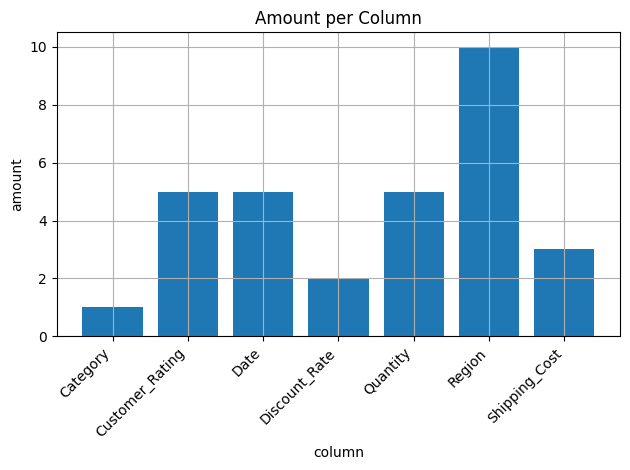

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_final["column"], df_final["amount"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("column")
plt.ylabel("amount")
plt.title("Amount data error per column")
plt.tight_layout()
plt.grid(True)
plt.show()

<Axes: xlabel='column'>

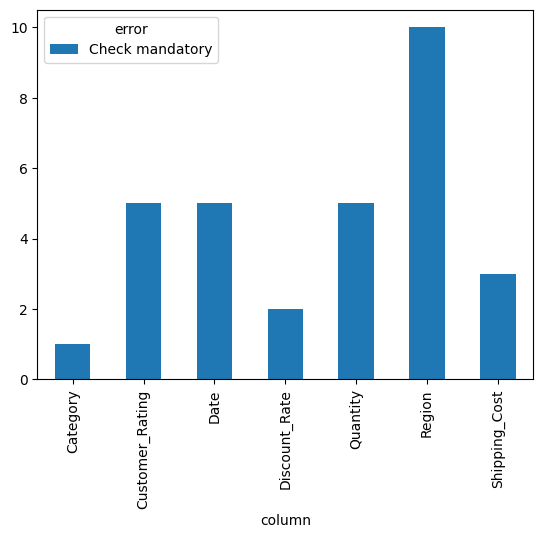

In [34]:
df_final.pivot(index="column", columns="error", values="amount").plot(
    kind="bar",
    stacked=True
)

In [66]:
class A:
    def __init__(self, name):
        self.__name = name
        self.run(self)

    @staticmethod
    def run(self):
        print(self.__name)

A("A")

A


In [77]:
class A:
    def __init__(self, prop):
        self.__prop = prop

    def run(self):
        print(self.__prop)

    def __call__(self):
        self.run()
A("a")() # a


a
